<a href="https://colab.research.google.com/github/so-yeon-hwang/DataSciencePractice/blob/main/FlightCustomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Customer Flight Activity.csv")

In [3]:
df.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


In [5]:
df.describe() # 392,936 rows

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000
mean,550527.519034,2017.513661,6.513661,1.294888,1941.440201,2027.172345,31.304263,5.635661
std,258604.580187,0.499814,3.445428,1.962675,3239.975889,3872.139841,126.653775,22.801167
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,327688.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,551833.000000,2018.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,772194.000000,2018.000000,10.000000,2.000000,3018.000000,3039.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,28.000000,67284.000000,100926.000000,876.000000,158.000000


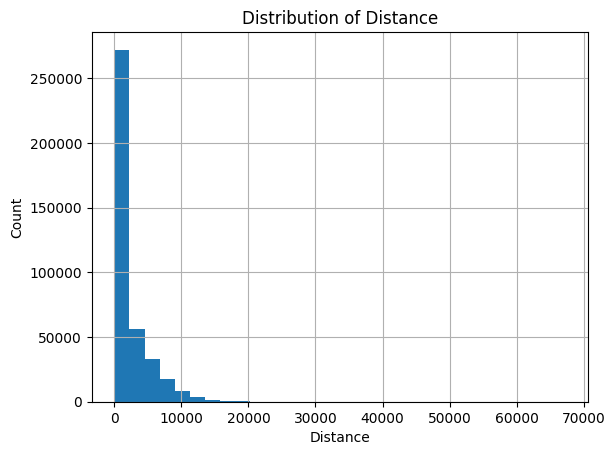

In [6]:
df['Distance'].hist(bins=30)
plt.xlabel('Distance')
plt.ylabel('Count')
plt.title('Distribution of Distance')
plt.show()

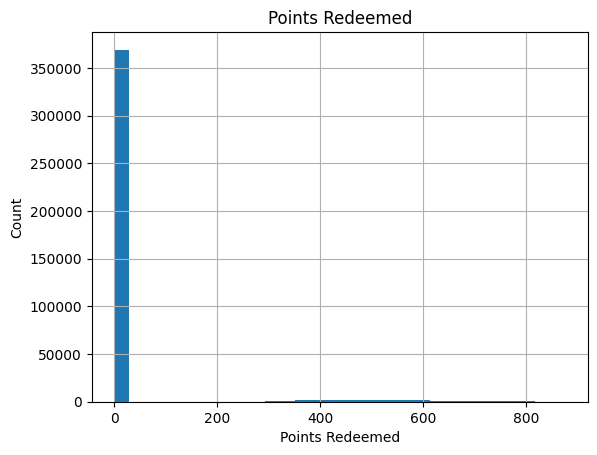

In [12]:
df['Points Redeemed'].hist(bins=30)
plt.xlabel('Points Redeemed')
plt.ylabel('Count')
plt.title('Points Redeemed')
plt.show()

# K-means Clustering : Customer Segmentation

In [16]:
# Aggregation
df.columns = df.columns.str.strip()

df_customer = df.groupby('Loyalty Number').agg({
    'Distance': 'mean',
    'Points Accumulated': 'mean',
    'Points Redeemed': 'mean',
    'Total Flights': 'mean'
}).reset_index()

# Redeem ratio
df_customer['Redeem Ratio'] = df_customer['Points Redeemed'] / df_customer['Points Accumulated'].replace(0, 1)

In [17]:
from sklearn.preprocessing import StandardScaler

features = ['Distance', 'Points Accumulated', 'Points Redeemed', 'Total Flights']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_customer[features])

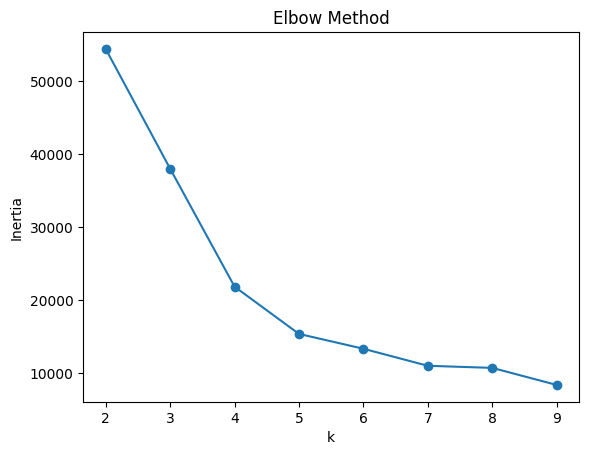

In [18]:
# Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'o-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


Based on the Elbow Method graph above, we'll gonna choose k = 5

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_customer['Cluster'] = kmeans.fit_predict(X_scaled)

In [20]:
df_customer.groupby('Cluster')[features].mean()

,Distance,Points Accumulated,Points Redeemed,Total Flights,Redeem Ratio
Cluster,,,,,
0,7811.960501,11717.940752,38.244934,5.115279,0.003410
1,438.249227,438.972459,5.893974,0.299756,0.012311
2,0.000000,0.000000,19.578704,0.000000,19.578704
3,2335.923620,2375.563784,22.409477,1.560733,0.010359
4,2428.199223,2465.372388,71.052547,1.621357,0.031581


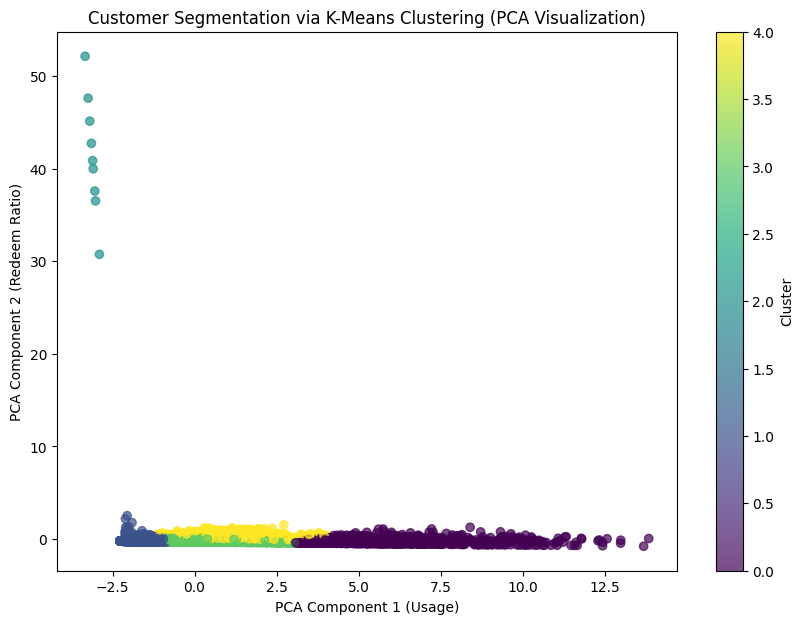

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. PCA conversion (2D)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_customer['PCA1'] = pca_components[:, 0]
df_customer['PCA2'] = pca_components[:, 1]

# 2. Scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_customer['PCA1'],
    df_customer['PCA2'],
    c=df_customer['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('PCA Component 1 (Usage)')
plt.ylabel('PCA Component 2 (Redeem Ratio)')
plt.title('Customer Segmentation via K-Means Clustering (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.show()


Purple : High usuage, decent level of Redeem ratio <br>
Yellow/Green : Medium usage, decent level of Redeem ratio <br>
Blue : Low usage, decent level of Redeem ratio
Mint : Outleir

In [22]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PCA1', 'PCA2']
)

pca_components


,Distance,Points Accumulated,Points Redeemed,Total Flights,Redeem Ratio
PCA1,0.564574,0.554337,0.242955,0.560699,-0.023574
PCA2,-0.015570,-0.027231,0.223676,-0.013368,0.974067


Key Componetns for each PCA <br>
- PCA1 : Distance, Total Flights, Points Accumulated (how often do they use us?)<br>
- PCA2 : Redeem Ratio (How often do they redeem?)

In [30]:
df_clean = df[(df['Points Accumulated'] > 0) &
              (df['Points Redeemed'] / df['Points Accumulated'] < 10)]

# ML : Points Prediction

In [32]:
df['Redeem_Flag'] = (df['Points Redeemed'] > 0).astype(int)
df['Redeem_Flag'].value_counts()

,count
Redeem_Flag,
0,369051
1,23885


In [34]:
df.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Redeem_Flag
0,100590,2018,6,12,15276,22914.0,0,0,0
1,100590,2018,7,12,9168,13752.0,0,0,0
2,100590,2018,5,4,6504,9756.0,0,0,0
3,100590,2018,10,0,0,0.0,512,92,1
4,100590,2018,2,0,0,0.0,0,0,0


In [40]:
from sklearn.model_selection import train_test_split

features = [
    'Distance',
    'Total Flights',
    'Points Accumulated',
    'Month',
    'Year'
]

X = df[features]
y = df['Redeem_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced')

In [43]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.68      0.80     73811
           1       0.11      0.64      0.19      4777

    accuracy                           0.68     78588
   macro avg       0.54      0.66      0.50     78588
weighted avg       0.91      0.68      0.76     78588



## Random Forest

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     73811
           1       0.12      0.10      0.11      4777

    accuracy                           0.90     78588
   macro avg       0.53      0.53      0.53     78588
weighted avg       0.89      0.90      0.90     78588

[[70126  3685]
 [ 4278   499]]
              Feature  Importance
2  Points Accumulated    0.413661
0            Distance    0.403744
1       Total Flights    0.103135
3               Month    0.068542
4                Year    0.010919


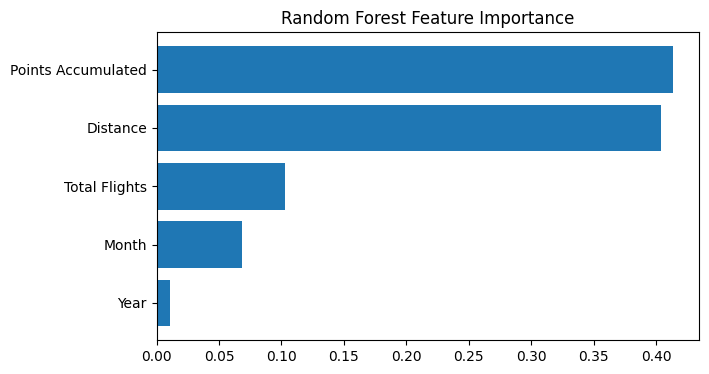

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Feature & Target
features = [
    'Distance',
    'Total Flights',
    'Points Accumulated',
    'Month',
    'Year'
]

X = df[features]
y = df['Redeem_Flag']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model generation
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Visualization
plt.figure(figsize=(7, 4))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

The Random Forest model indicates that accumulated points and historical travel activity exert the strongest influence on redemption behavior. However, model performance suggests these variables alone do not fully explain customer redemption decisions, highlighting an opportunity for additional behavioral and temporal feature engineering.